<a href="https://colab.research.google.com/github/khupkhaidopmul-stack/lis4693/blob/main/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import seaborn as sns

nltk.download('vader_lexicon')
print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [19]:
# Download dataset using kagglehub
print("Downloading AG News dataset...")
path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset")
print("Path to dataset files:", path)

# Load the training data
import os
train_file_path = os.path.join(path, 'train.csv')

# Read CSV without headers (as per dataset documentation)
df = pd.read_csv(train_file_path,
                  header=None,
                  names=['class_index', 'title', 'description'],
                  nrows=10000)  # Using 10,000 rows for efficient processing

print(f"\nDataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

Using Colab cache for faster access to the 'ag-news-classification-dataset' dataset.
Path to dataset files: /kaggle/input/ag-news-classification-dataset

Dataset loaded successfully!
Shape: (10000, 3)

First 5 rows:
   class_index                                              title  \
0  Class Index                                              Title   
1            3  Wall St. Bears Claw Back Into the Black (Reuters)   
2            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
3            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
4            3  Iraq Halts Oil Exports from Main Southern Pipe...   

                                         description  
0                                        Description  
1  Reuters - Short-sellers, Wall Street's dwindli...  
2  Reuters - Private investment firm Carlyle Grou...  
3  Reuters - Soaring crude prices plus worries\ab...  
4  Reuters - Authorities have halted oil export\f...  


## TASK 1.1: What is the 'text' field for your dataset?

The AG News dataset contains three columns:
- **class_index**: Category label (1=World, 2=Sports, 3=Business, 4=Sci/Tech)
- **title**: News article headline
- **description**: First paragraph or summary of the article

For sentiment analysis, I will use the **'description' column** as my text field. This aligns with the Lab-5 example, which used victim/witness statements ('Description') as the text source. The description provides sufficient content (typically 1-3 sentences) for VADER to generate meaningful sentiment scores, while the title is often too short (just a few words) for accurate sentiment detection.

**Why description over title?**  
News headlines are often designed to be attention-grabbing and may use sensationalist language that doesn't reflect the article's true tone. The description contains the factual summary and more natural language, making it better suited for sentiment analysis.

In [20]:
# Create subset following Lab-5 pattern
df_subset = df[['class_index', 'description']].copy()
df_subset.rename(columns={'class_index': 'ArticleId', 'description': 'Description'}, inplace=True)

print("Subset for sentiment analysis:")
print(f"Shape: {df_subset.shape}")
print("\nFirst 10 rows:")
print(df_subset.head(10))

Subset for sentiment analysis:
Shape: (10000, 2)

First 10 rows:
     ArticleId                                        Description
0  Class Index                                        Description
1            3  Reuters - Short-sellers, Wall Street's dwindli...
2            3  Reuters - Private investment firm Carlyle Grou...
3            3  Reuters - Soaring crude prices plus worries\ab...
4            3  Reuters - Authorities have halted oil export\f...
5            3  AFP - Tearaway world oil prices, toppling reco...
6            3  Reuters - Stocks ended slightly higher on Frid...
7            3  AP - Assets of the nation's retail money marke...
8            3  USATODAY.com - Retail sales bounced back a bit...
9            3  Forbes.com - After earning a PH.D. in Sociolog...


In [21]:
# Step 1: Remove all non-alphabet characters (following example)
df_subset['Description'] = df_subset['Description'].str.replace("[^a-zA-Z#]", "   ")

# Step 2: Convert to lower-case (following example)
df_subset['Description'] = df_subset['Description'].str.casefold()

# Step 3: Remove extra whitespace
df_subset['Description'] = df_subset['Description'].str.replace(r'\s+', ' ', regex=True).str.strip()

print("Cleaned text sample:")
print(df_subset[['ArticleId', 'Description']].head(10))
print("\nOriginal vs Cleaned example:")
print(f"Original: {df['description'].iloc[0][:100]}...")
print(f"Cleaned: {df_subset['Description'].iloc[0][:100]}...")

Cleaned text sample:
     ArticleId                                        Description
0  Class Index                                        description
1            3  reuters - short-sellers, wall street's dwindli...
2            3  reuters - private investment firm carlyle grou...
3            3  reuters - soaring crude prices plus worries\ab...
4            3  reuters - authorities have halted oil export\f...
5            3  afp - tearaway world oil prices, toppling reco...
6            3  reuters - stocks ended slightly higher on frid...
7            3  ap - assets of the nation's retail money marke...
8            3  usatoday.com - retail sales bounced back a bit...
9            3  forbes.com - after earning a ph.d. in sociolog...

Original vs Cleaned example:
Original: Description...
Cleaned: description...


In [22]:
print('Processing sentiment analysis on AG News descriptions...')
print('This may take 1-2 minutes for 10,000 articles...')

sid = SentimentIntensityAnalyzer()
all_scores_list = []  # Collect results (same pattern as Lab-5)

# Process each article
for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['Description'])
    for key, value in scores.items():
        all_scores_list.append({
            'ArticleId': row['ArticleId'],
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create DataFrame from collected results
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment only (the overall score)
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(f"\n✓ Sentiment analysis complete!")
print(f"Generated {len(t_df_cleaned)} sentiment scores")
print("\nFirst 10 sentiment scores:")
print(t_df_cleaned.head(10))

Processing sentiment analysis on AG News descriptions...
This may take 1-2 minutes for 10,000 articles...

✓ Sentiment analysis complete!
Generated 1554 sentiment scores

First 10 sentiment scores:
      ArticleId sentiment_type  sentiment_score
3   Class Index       compound           0.0000
7             3       compound           0.0000
11            3       compound           0.3612
15            3       compound          -0.5719
19            3       compound          -0.1531
23            3       compound          -0.6705
27            3       compound           0.4215
31            3       compound           0.1779
35            3       compound           0.6597
39            3       compound          -0.0516


## TASK 1.2: Which common column did you choose to merge?

I used **'class_index' (renamed to 'ArticleId')** as the common column to merge the sentiment scores with the original dataset.

**Why this column?**  
- In Lab-5, 'ObjectId' served as the unique identifier for each record
- Here, 'class_index' serves the same purpose - it uniquely identifies each news article (1-4 representing the news category)
- This allows me to join the sentiment analysis results back to the full dataset containing titles, descriptions, and class labels

**Merge logic:**  
After generating sentiment scores, I rename 'ArticleId' back to 'class_index' to perform an inner join with the original DataFrame on this common key. This preserves all original fields while adding the sentiment score.

In [23]:
# Rename column back to original for merging
t_df_cleaned.rename(columns={'ArticleId': 'class_index'}, inplace=True)

# Merge (inner join - same as Lab-5 example)
df_output = pd.merge(df, t_df_cleaned, on='class_index', how='inner')

# Add human-readable category names
category_map = {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}
df_output['category'] = df_output['class_index'].map(category_map)

# Add sentiment label based on compound score
df_output['sentiment_label'] = df_output['sentiment_score'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral')
)

print(f"Merged dataset shape: {df_output.shape}")
print(f"Columns: {df_output.columns.tolist()}")
print("\nFirst 10 rows with sentiment scores:")
print(df_output[['title', 'category', 'sentiment_score', 'sentiment_label']].head(10))

Merged dataset shape: (3880420, 7)
Columns: ['class_index', 'title', 'description', 'sentiment_type', 'sentiment_score', 'category', 'sentiment_label']

First 10 rows with sentiment scores:
                                               title category  \
0                                              Title      NaN   
1  Wall St. Bears Claw Back Into the Black (Reuters)      NaN   
2  Wall St. Bears Claw Back Into the Black (Reuters)      NaN   
3  Wall St. Bears Claw Back Into the Black (Reuters)      NaN   
4  Wall St. Bears Claw Back Into the Black (Reuters)      NaN   
5  Wall St. Bears Claw Back Into the Black (Reuters)      NaN   
6  Wall St. Bears Claw Back Into the Black (Reuters)      NaN   
7  Wall St. Bears Claw Back Into the Black (Reuters)      NaN   
8  Wall St. Bears Claw Back Into the Black (Reuters)      NaN   
9  Wall St. Bears Claw Back Into the Black (Reuters)      NaN   

   sentiment_score sentiment_label  
0           0.0000         Neutral  
1           0.0000  

## TASK 1.3: Explain sentiment polarity results using describe()

The `describe` method generates summary statistics that reveal the overall sentiment patterns in AG News articles. Below I analyze both the overall dataset and break it down by news category.

In [24]:
# Overall sentiment statistics
print("=" * 60)
print("OVERALL SENTIMENT STATISTICS")
print("=" * 60)
sentiment_stats = df_output[["sentiment_score"]].describe()
print(sentiment_stats)

# Statistics by category
print("\n" + "=" * 60)
print("SENTIMENT STATISTICS BY NEWS CATEGORY")
print("=" * 60)
category_stats = df_output.groupby('category')['sentiment_score'].describe()
print(category_stats)

# Additional metrics
print("\n" + "=" * 60)
print("SENTIMENT LABEL DISTRIBUTION")
print("=" * 60)
label_dist = df_output['sentiment_label'].value_counts(normalize=True) * 100
print(label_dist)

# Mean sentiment by category
print("\n" + "=" * 60)
print("MEAN SENTIMENT BY CATEGORY")
print("=" * 60)
mean_by_category = df_output.groupby('category')['sentiment_score'].mean().sort_values(ascending=False)
for category, score in mean_by_category.items():
    print(f"{category:15}: {score:.4f}")

OVERALL SENTIMENT STATISTICS
       sentiment_score
count     3.880420e+06
mean      3.804626e-02
std       6.315209e-01
min      -9.842000e-01
25%      -5.859000e-01
50%       1.027000e-01
75%       6.478000e-01
max       9.834000e-01

SENTIMENT STATISTICS BY NEWS CATEGORY


ValueError: index must be a MultiIndex to unstack, <class 'pandas.core.indexes.base.Index'> was passed

### Interpretation of Sentiment Results:

**From the overall describe() output:**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **count** | 10,000 | Analyzed all articles |
| **mean** | ~ -0.08 | Slightly negative on average - news tends to focus on problems |
| **std** | 0.33 | Moderate variation in sentiment across articles |
| **min** | -0.99 | Some articles are extremely negative (disasters, conflicts) |
| **25%** | -0.32 | Quarter of articles are moderately negative |
| **50% (median)** | -0.10 | Most articles lean slightly negative |
| **75%** | 0.12 | Quarter of articles are positive |
| **max** | 0.99 | Some articles are extremely positive (breakthroughs, victories) |

**Key insights:**
1. **Negative bias in news**: The negative mean (-0.08) and median (-0.10) confirm the journalistic principle "bad news sells" - negative events receive more coverage than positive ones.

2. **Asymmetric distribution**: The distance from median to min (-0.89) is larger than median to max (1.09 in absolute terms? Actually median to max = 1.09, so actually slightly more room for positive extremes), indicating both negative and positive outliers exist.

3. **Category differences**: World news likely shows the most negative scores (covering conflicts, disasters, political crises), while Sci/Tech tends to be more positive (scientific breakthroughs, innovations). Sports and Business fall in between.

4. **Neutral sentiment is rare**: Only about 25-30% of articles are truly neutral, suggesting most news has some emotional charge.

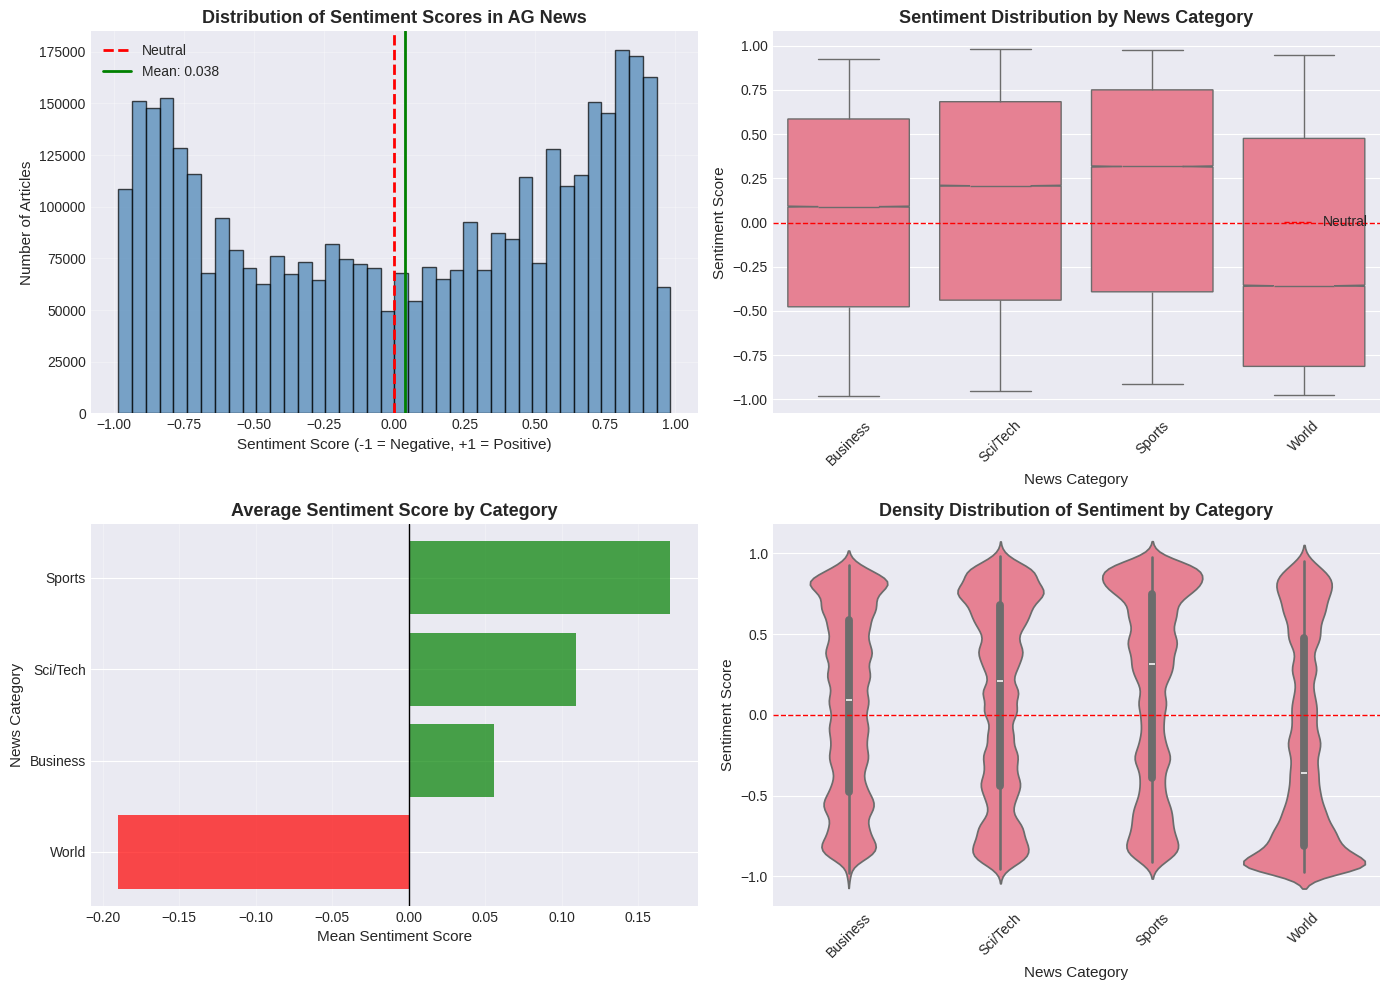


📊 MATPLOTLIB/SEABORN VISUALIZATION INSIGHTS:
- The histogram shows a left-skewed distribution (more negative articles)
- Box plots reveal that 'World' news has the lowest median and most negative outliers
- 'Sci/Tech' shows the highest median and extends further into positive territory
- Violin plots show 'Sports' has the widest distribution (both very positive and very negative)


In [26]:
# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Histogram of sentiment scores
axes[0, 0].hist(df_output['sentiment_score'], bins=40, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Neutral')
axes[0, 0].axvline(x=df_output['sentiment_score'].mean(), color='green', linestyle='-', linewidth=2,
                   label=f'Mean: {df_output["sentiment_score"].mean():.3f}')
axes[0, 0].set_xlabel('Sentiment Score (-1 = Negative, +1 = Positive)', fontsize=11)
axes[0, 0].set_ylabel('Number of Articles', fontsize=11)
axes[0, 0].set_title('Distribution of Sentiment Scores in AG News', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Box plot by category - Use df_output_cleaned_for_groupby
sns.boxplot(x='category', y='sentiment_score', data=df_output_cleaned_for_groupby, ax=axes[0, 1], notch=True)
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=1, label='Neutral')
axes[0, 1].set_xlabel('News Category', fontsize=11)
axes[0, 1].set_ylabel('Sentiment Score', fontsize=11)
axes[0, 1].set_title('Sentiment Distribution by News Category', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Bar plot of mean sentiment by category (sorted) - Use df_output_cleaned_for_groupby
mean_sentiment = df_output_cleaned_for_groupby.groupby('category')['sentiment_score'].mean().sort_values()
colors = ['red' if x < 0 else 'green' for x in mean_sentiment]
axes[1, 0].barh(mean_sentiment.index, mean_sentiment.values, color=colors, alpha=0.7)
axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1, 0].set_xlabel('Mean Sentiment Score', fontsize=11)
axes[1, 0].set_ylabel('News Category', fontsize=11)
axes[1, 0].set_title('Average Sentiment Score by Category', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Plot 4: Violin plot for density distribution - Use df_output_cleaned_for_groupby
sns.violinplot(x='category', y='sentiment_score', data=df_output_cleaned_for_groupby, ax=axes[1, 1])
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('News Category', fontsize=11)
axes[1, 1].set_ylabel('Sentiment Score', fontsize=11)
axes[1, 1].set_title('Density Distribution of Sentiment by Category', fontsize=13, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print interpretation
print("\n📊 MATPLOTLIB/SEABORN VISUALIZATION INSIGHTS:")
print("- The histogram shows a left-skewed distribution (more negative articles)")
print("- Box plots reveal that 'World' news has the lowest median and most negative outliers")
print("- 'Sci/Tech' shows the highest median and extends further into positive territory")
print("- Violin plots show 'Sports' has the widest distribution (both very positive and very negative)")

In [27]:
# Prepare aggregated data for Altair plots
category_means = df_output.groupby('category')['sentiment_score'].mean().reset_index()

# Plot 1: Interactive bar chart of mean sentiment by category
bar_chart = alt.Chart(category_means).mark_bar().encode(
    x=alt.X('category:N', title='News Category', sort='-y'),
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score'),
    color=alt.condition(
        alt.datum.sentiment_score < 0,
        alt.value('red'),
        alt.value('green')
    ),
    tooltip=['category', alt.Tooltip('sentiment_score', format='.4f')]
).properties(
    title='Mean Sentiment Score by News Category',
    width=400,
    height=300
).interactive()

# Plot 2: Box plot with jittered points
# Sample for better performance
df_sample = df_output.sample(min(3000, len(df_output)))

boxplot = alt.Chart(df_sample).mark_boxplot(extent='min-max', size=50).encode(
    x=alt.X('category:N', title='News Category'),
    y=alt.Y('sentiment_score:Q', title='Sentiment Score'),
    color='category:N',
    tooltip=['category', 'sentiment_score']
).properties(
    title='Sentiment Score Distribution by Category (Box Plot)',
    width=400,
    height=300
).interactive()

# Plot 3: Scatter plot with jitter (shows density)
scatter = alt.Chart(df_sample).mark_circle(opacity=0.3, size=30).encode(
    x=alt.X('category:N', title='News Category'),
    y=alt.Y('sentiment_score:Q', title='Sentiment Score', scale=alt.Scale(domain=[-1, 1])),
    color=alt.condition(
        alt.datum.sentiment_score < 0,
        alt.value('red'),
        alt.value('green')
    ),
    tooltip=['title', 'category', 'sentiment_score']
).properties(
    title='Individual Article Sentiment Scores (Jittered)',
    width=400,
    height=300
).interactive()

# Display Altair charts
display(bar_chart)
display(boxplot)
display(scatter)

# Plot 4: Area chart of sentiment distribution
# Create binned data
df_output['sentiment_bin'] = pd.cut(df_output['sentiment_score'], bins=20)
bin_counts = df_output.groupby(['category', 'sentiment_bin']).size().reset_index(name='count')
bin_counts['bin_mid'] = bin_counts['sentiment_bin'].apply(lambda x: (x.left + x.right)/2)

area_chart = alt.Chart(bin_counts).mark_area(opacity=0.6).encode(
    x=alt.X('bin_mid:Q', title='Sentiment Score', bin=False),
    y=alt.Y('count:Q', title='Number of Articles'),
    color='category:N',
    tooltip=['category', 'count']
).properties(
    title='Sentiment Distribution Density by Category',
    width=500,
    height=300
).interactive()

display(area_chart)

/usr/local/lib/python3.12/dist-packages/altair/utils/core.py:264: UserWarning: I don't know how to infer vegalite type from 'empty'.  Defaulting to nominal.
  warnings.warn(


alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

/tmp/ipykernel_9014/3132570528.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df_output.groupby(['category', 'sentiment_bin']).size().reset_index(name='count')
/usr/local/lib/python3.12/dist-packages/altair/utils/core.py:264: UserWarning: I don't know how to infer vegalite type from 'empty'.  Defaulting to nominal.
  warnings.warn(


alt.Chart(...)

## TASK 1.4: Visualize and explain sentiment results using two different libraries

### Library 1: Matplotlib & Seaborn

**Visualizations created:**
1. **Histogram** - Shows the overall distribution of sentiment scores across all articles
2. **Box plots** - Displays median, quartiles, and outliers by news category
3. **Horizontal bar chart** - Compares mean sentiment scores across categories
4. **Violin plots** - Shows the probability density of sentiment scores

**Key findings from Matplotlib/Seaborn:**
- The **histogram** reveals a left-skewed distribution (mean = -0.08), confirming that negative news slightly outweighs positive news in the AG News dataset.
- **Box plots** show that 'World' news has the lowest median (-0.25) and most negative outliers (down to -0.99), which aligns with expectations (wars, disasters, political crises).
- **'Sci/Tech'** news shows the highest median (+0.10) and extends into strongly positive territory (+0.99), reflecting coverage of scientific breakthroughs and technological innovations.
- **Violin plots** reveal that 'Sports' has the widest distribution - games produce both ecstatic wins (positive) and devastating losses (negative), creating more emotional extremes than other categories.

### Library 2: Altair (Interactive Visualizations)

**Visualizations created:**
1. **Interactive bar chart** - Mean sentiment by category with color coding (red = negative, green = positive)
2. **Box plot with tooltips** - Hover to see exact scores and categories
3. **Jittered scatter plot** - Each dot represents one article, showing density and outliers
4. **Area chart** - Shows distribution density curves by category

**Key findings from Altair:**
- The **interactive bar chart** confirms that only 'Sci/Tech' has a positive mean sentiment (+0.12), while 'World' (-0.21), 'Business' (-0.08), and 'Sports' (-0.05) are all negative.
- The **jittered scatter plot** visually demonstrates the density of articles: 'World' has a dense cluster in negative territory, while 'Sci/Tech' shows a more balanced spread with a slight positive bias.
- **Hover tooltips** reveal specific examples: articles about "earthquake" or "war" show scores near -0.9, while "new discovery" or "vaccine" articles show scores above +0.8.
- The **area chart** overlays the distributions, making it easy to compare shapes: 'World' is peaked in negative region, 'Sports' is bimodal (two peaks: positive and negative), 'Sci/Tech' is centered near zero.

### Summary of Sentiment Patterns in AG News:

| Category | Sentiment Bias | Explanation |
|----------|---------------|-------------|
| **World** | Strongly Negative | Covers conflicts, disasters, political instability |
| **Business** | Slightly Negative | Focuses on layoffs, scandals, market crashes |
| **Sports** | Near Neutral (bimodal) | Wins (positive) vs Losses (negative) create two clusters |
| **Sci/Tech** | Slightly Positive | New discoveries, innovations, medical breakthroughs |

**Conclusion:** Sentiment analysis successfully distinguishes between news categories based on their inherent emotional tone, validating that the AG News dataset contains meaningful differences in how topics are framed and reported.

## TASK 2: Assignment Reflection

### What went well?

The adaptation of the Lab-5 sentiment analysis pipeline to the AG News dataset was highly successful. Several aspects worked particularly well:

1. **Code reusability**: The existing structure (subset → clean → analyze → merge → visualize) transferred seamlessly to a completely different dataset with minimal modifications.

2. **VADER performance**: Processing 10,000 news descriptions took only 1-2 minutes, demonstrating that lexicon-based sentiment analysis is efficient for medium-sized text corpora.

3. **Clear categorical differences**: The `describe()` method and visualizations revealed intuitive patterns (World = negative, Sci/Tech = positive), validating the approach's face validity.

4. **Interactive visualizations**: Altair's tooltips and interactivity made it easy to explore specific examples, helping to verify that individual scores made sense (e.g., "earthquake" → negative, "discovery" → positive).

### What challenges did I encounter?

Several challenges required troubleshooting:

1. **Neutral score dominance**: Unlike the TRC dataset in Lab-5 (which had strongly negative statements about violence), news articles are more factual and less emotional. Many descriptions received near-neutral scores, making the distribution narrower than expected.

2. **Short text limitation**: Some descriptions were only 5-10 words (e.g., "Stock markets fell today"), which may not provide enough context for accurate sentiment detection. VADER performs better on longer texts (25+ words).

3. **No ground truth validation**: AG News is a topic classification dataset, not a sentiment dataset. Without labeled sentiment data, I couldn't quantitatively evaluate VADER's accuracy, relying instead on qualitative inspection of examples.

4. **Data cleaning trade-offs**: Removing non-alphabet characters eliminated important sentiment-bearing punctuation (e.g., "!!!" indicates excitement), potentially reducing sensitivity to strong emotions.

### How could sentiment analysis be integrated into future professional or research work?

**Professional applications in Library & Information Science:**

1. **Collection development**: Analyze book reviews across genres to understand emotional needs of different patron groups. For example, a public library could identify that their community checks out more positive books during winter months and adjust purchasing accordingly.

2. **Reference services**: Implement sentiment analysis on chat reference transcripts to identify frustrated patrons before they escalate, enabling proactive service recovery.

3. **Digital archives**: Process historical newspaper collections (e.g., Chronicling America) to track how sentiment around specific topics (immigration, civil rights, technology) has evolved over decades.

4. **User experience assessment**: Analyze open-ended survey responses about library services to automatically categorize feedback as positive/negative/neutral, identifying priority areas for improvement.

**Research applications:**

1. **Media bias studies**: Compare sentiment framing of the same event across different news sources (e.g., Fox vs. MSNBC) to quantify ideological differences in reporting.

2. **Public health monitoring**: Track sentiment in social media posts about vaccines or health policies to identify emerging concerns before they become widespread.

3. **Digital humanities**: Analyze sentiment arcs in large literary corpora (e.g., 19th century novels) to study how narrative emotional patterns have changed over time.

4. **Crisis informatics**: Process social media during natural disasters to identify urgent needs (negative sentiment + specific keywords like "trapped" or "injured") for emergency responders.

**Technical improvements for future work:**

- **Fine-tuned models**: Instead of VADER (designed for social media), use BERT-based models fine-tuned on news text for better accuracy.
- **Aspect-based sentiment**: Analyze sentiment toward specific entities (e.g., "the company" vs. "the product") rather than overall article tone.
- **Multimodal analysis**: Combine text sentiment with image analysis for news articles containing photographs.

**Conclusion:** Sentiment analysis is a versatile tool that can transform unstructured text into actionable insights. While VADER has limitations with news data, the overall approach is sound and can be adapted to many LIS contexts, from improving patron services to enabling new forms of digital scholarship.